In [9]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/wknn_experiment'

errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

print(config)

{'max_wknn_k': 20, 'rf_param': 'sinr', 'operator_choice': [10], 'n_runs': 30, 'campaigns': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'runtime': 3960.0579023361206}


In [14]:
columns = [str(i) for i in range(1, 11)]
errors_df = errors_df[columns]

best_k = errors_df['2'].mean()

best_k

np.float64(4.154952419316689)

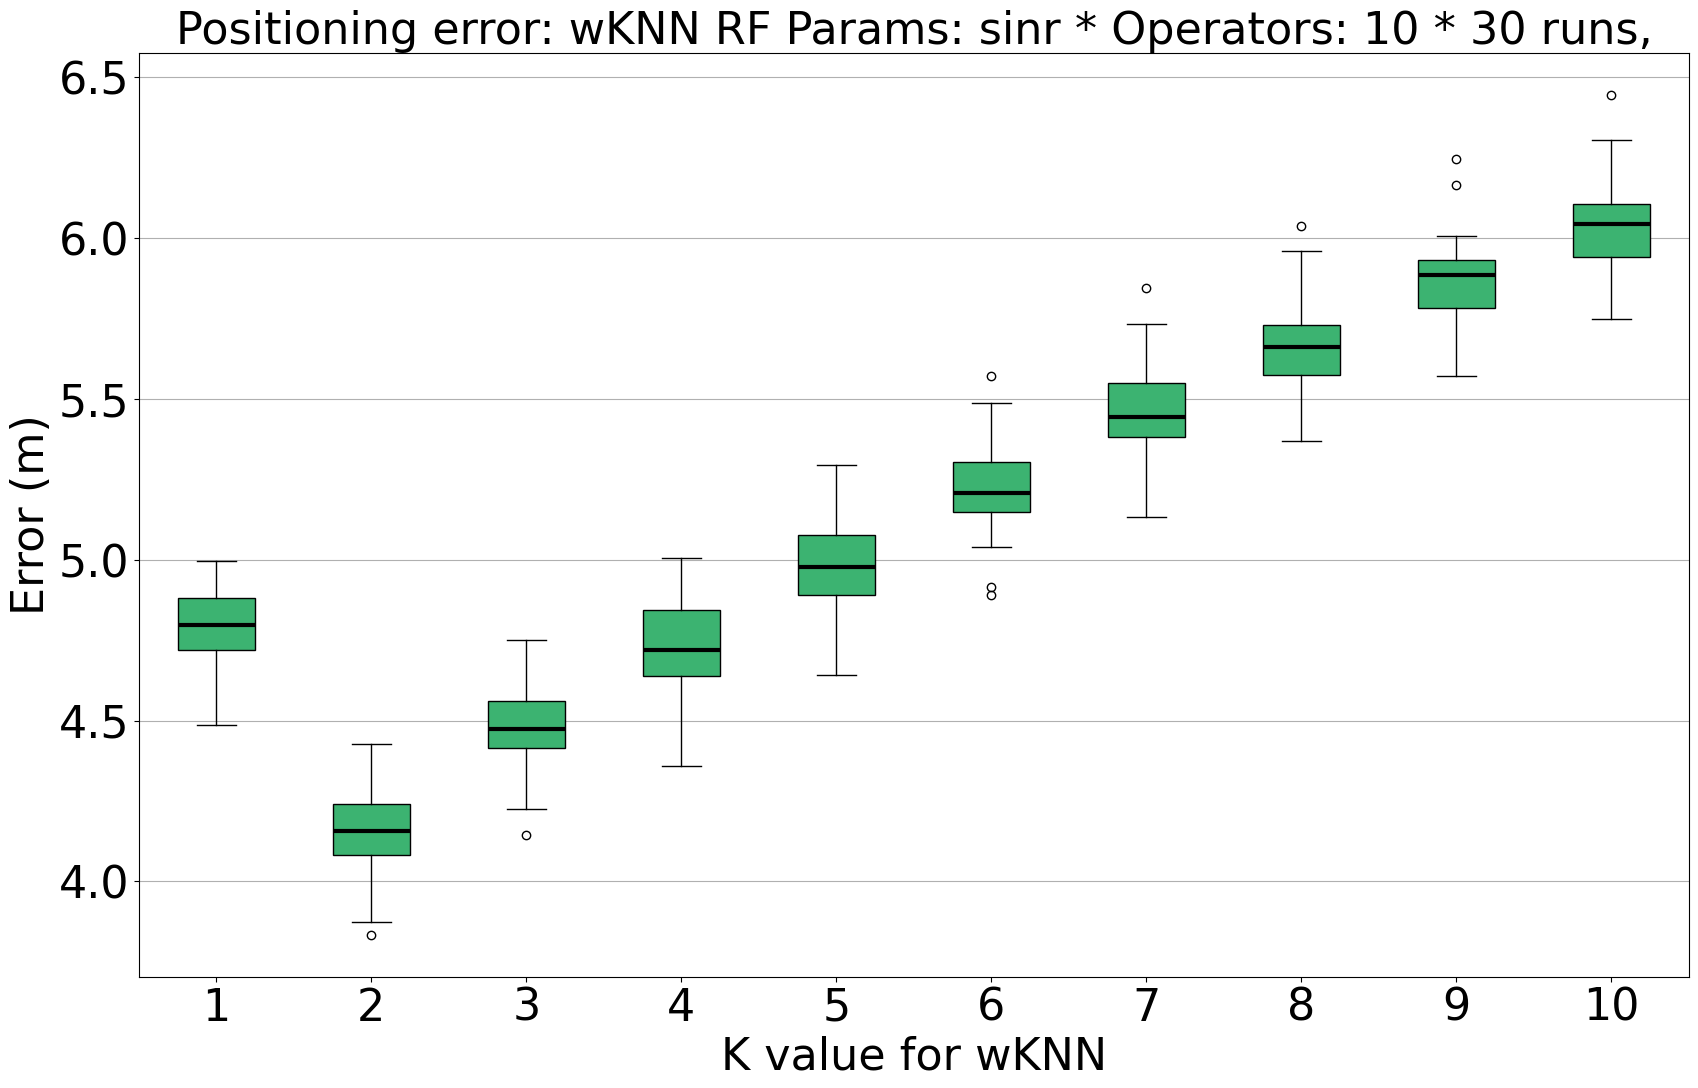

In [11]:
from scripts.utils import operators_to_str
from scripts.plotting import make_boxplot

param_str = f'RF Params: {config["rf_param"]}'
operator_str = f'Operators: {operators_to_str(config["operator_choice"])}'

title_string = f'wKNN {param_str} * {operator_str} * {config["n_runs"]} runs,'
make_boxplot(
    df=errors_df,
    title=f'Positioning error: {title_string}',
    x_label='K value for wKNN',
    y_label='Error (m)',
    color='mediumseagreen',
)
